In [96]:
# ── CELDA 1: Configuración de entorno e Importaciones ────────────────
import sys
import os
# 🔥 Crucial: Asegura que Jupyter encuentre la carpeta 'scripts' al estar en 'notebooks/'
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from scripts.database import engine

# Configuración visual global
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Entorno configurado correctamente.")

✅ Entorno configurado correctamente.


In [97]:
# ── CELDA 2: Carga y Reemplazo de NaNs ────────────────────────────────
QUERY = "SELECT pais, anio, indicador, valor FROM worldbank_registros" #
df_raw = pd.read_sql(QUERY, engine)

# 1. Eliminar duplicados técnicos para evitar errores en el pivoteo
df_raw = df_raw.drop_duplicates(subset=["pais", "anio", "indicador"], keep="first")

# 2. Pivotar (aquí se generan los NaNs donde no hay cruce de indicadores)
df_pivot = df_raw.pivot_table(index=["pais", "anio"], columns="indicador", values="valor").reset_index()

# 3. Renombrar columnas dinámicamente
rename_map = {}
for col in df_pivot.columns:
    c_lower = str(col).lower()
    if "gdp" in c_lower or "pib" in c_lower: rename_map[col] = 'pib'
    elif "population" in c_lower or "poblacion" in c_lower: rename_map[col] = 'poblacion'
    elif "inflation" in c_lower or "inflacion" in c_lower: rename_map[col] = 'inflacion'

df_model = df_pivot.rename(columns=rename_map).copy() #

# 4. 🔥 ESTRATEGIA DE REEMPLAZO TOTAL (Imputación por país)
# Rellenamos los huecos basándonos en la historia de cada país
for col in ['pib', 'poblacion', 'inflacion']:
    if col in df_model.columns:
        df_model[col] = df_model.groupby('pais')[col].transform(
            lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
        )
        # Aseguramos valores positivos mínimos para los logaritmos
        df_model[col] = df_model[col].clip(lower=0.01)

# 5. Transformaciones Logarítmicas
df_model['log_pib'] = np.log(df_model['pib'])
df_model['log_poblacion'] = np.log(df_model['poblacion'])

print(f"✅ Reemplazo completado. Dataset listo: {df_model.shape[0]} registros conservados.")

✅ Reemplazo completado. Dataset listo: 650 registros conservados.


In [86]:
# ── CELDA 3: Definición de Predictores (X) y Objetivo (y) ─────────────
# Usamos población e inflación (X múltiple) para predecir el PIB (y)
X = df_model[['log_poblacion', 'inflacion']].values
y = df_model['log_pib'].values

print(f"Vectores creados - X (Múltiple): {X.shape}, y (Objetivo): {y.shape}")

Vectores creados - X (Múltiple): (650, 2), y (Objetivo): (650,)


In [103]:
# ── CELDA 4: Función de evaluación con doble gráfica ──────────────────
def evaluar_modelo_multiple(X, y, test_size, label, resultados):
    # 1. División de datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # 2. Entrenamiento del Random Forest (Bosque Aleatorio)
    modelo = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # 3. Cálculo de métricas
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    resultados.append({'Split': label, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    
    # 4. Generación de las DOS gráficas (Residuos y Real vs Predicho)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico A: Residuos
    residuos = y_test - y_pred
    sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, ax=axes[0], color='dodgerblue')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    lowess = sm.nonparametric.lowess(residuos, y_pred, frac=0.3)
    axes[0].plot(lowess[:, 0], lowess[:, 1], color='darkorange', linewidth=2)
    axes[0].set_title(f'Residuos - Split {label}', fontweight='bold')
    axes[0].set_xlabel('Log PIB Predicho')
    axes[0].set_ylabel('Error (Residuo)')
    
    # Gráfico B: Predicción vs Realidad
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red', 'ls':'--'}, ax=axes[1])
    axes[1].set_title(f'Real vs Predicho - Split {label} (R²: {r2:.4f})', fontweight='bold')
    axes[1].set_xlabel('Valor Real (Log PIB)')
    axes[1].set_ylabel('Valor Predicho (Log PIB)')
    
    plt.tight_layout()
    plt.show()
    
    return modelo

resumen_multiple = []

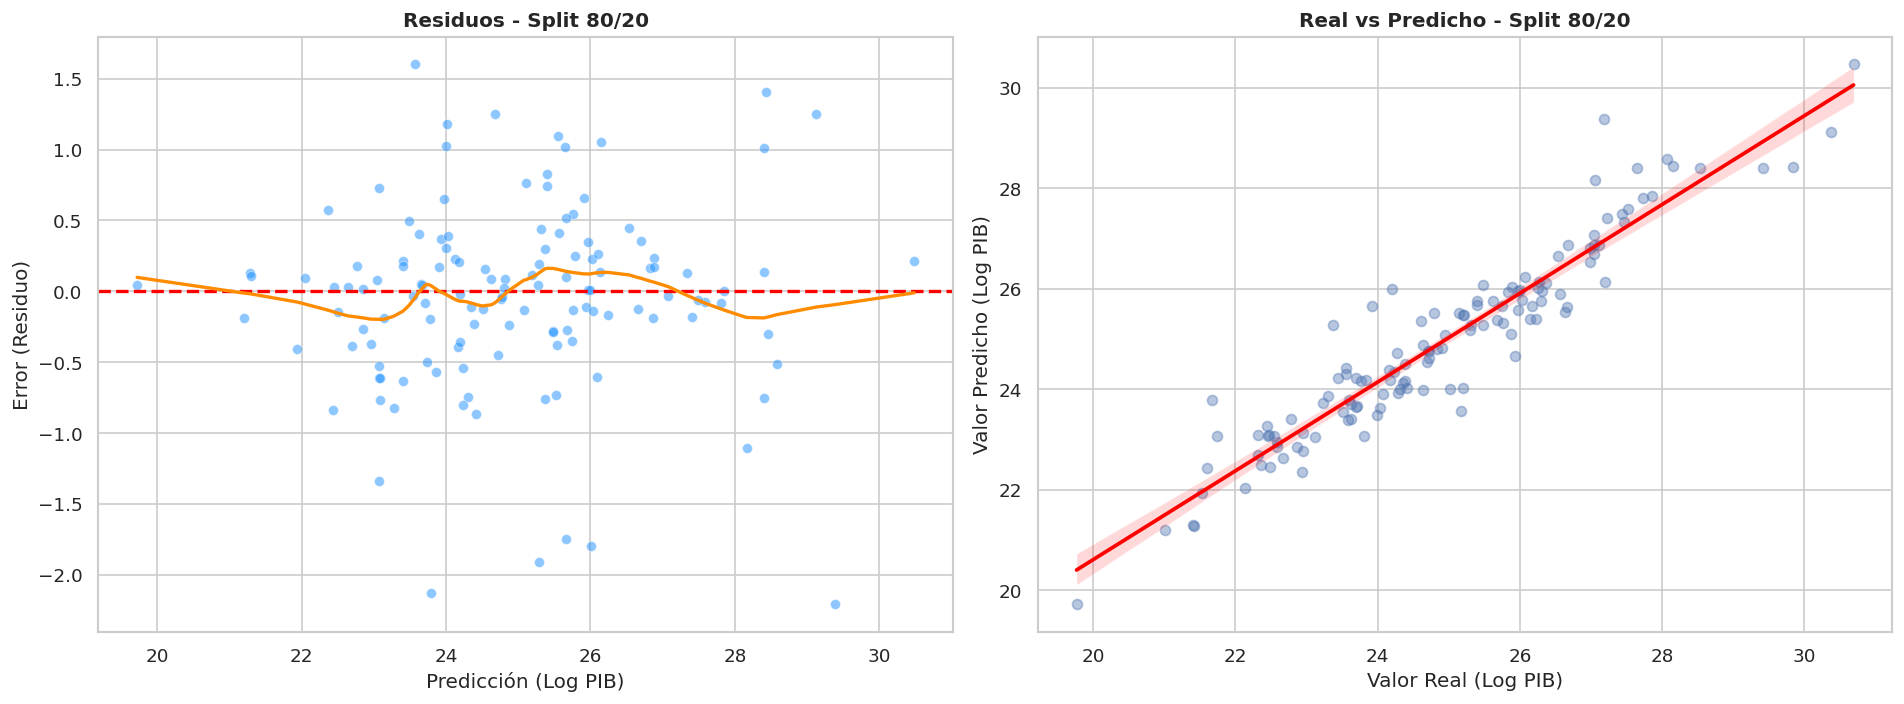

📈 80/20 finalizado. R²: 0.8962 | RMSE: 0.6444


In [104]:
modelo_final = evaluar_modelo_multiple_completo(X, y, 0.20, "80/20", resumen_multiple)

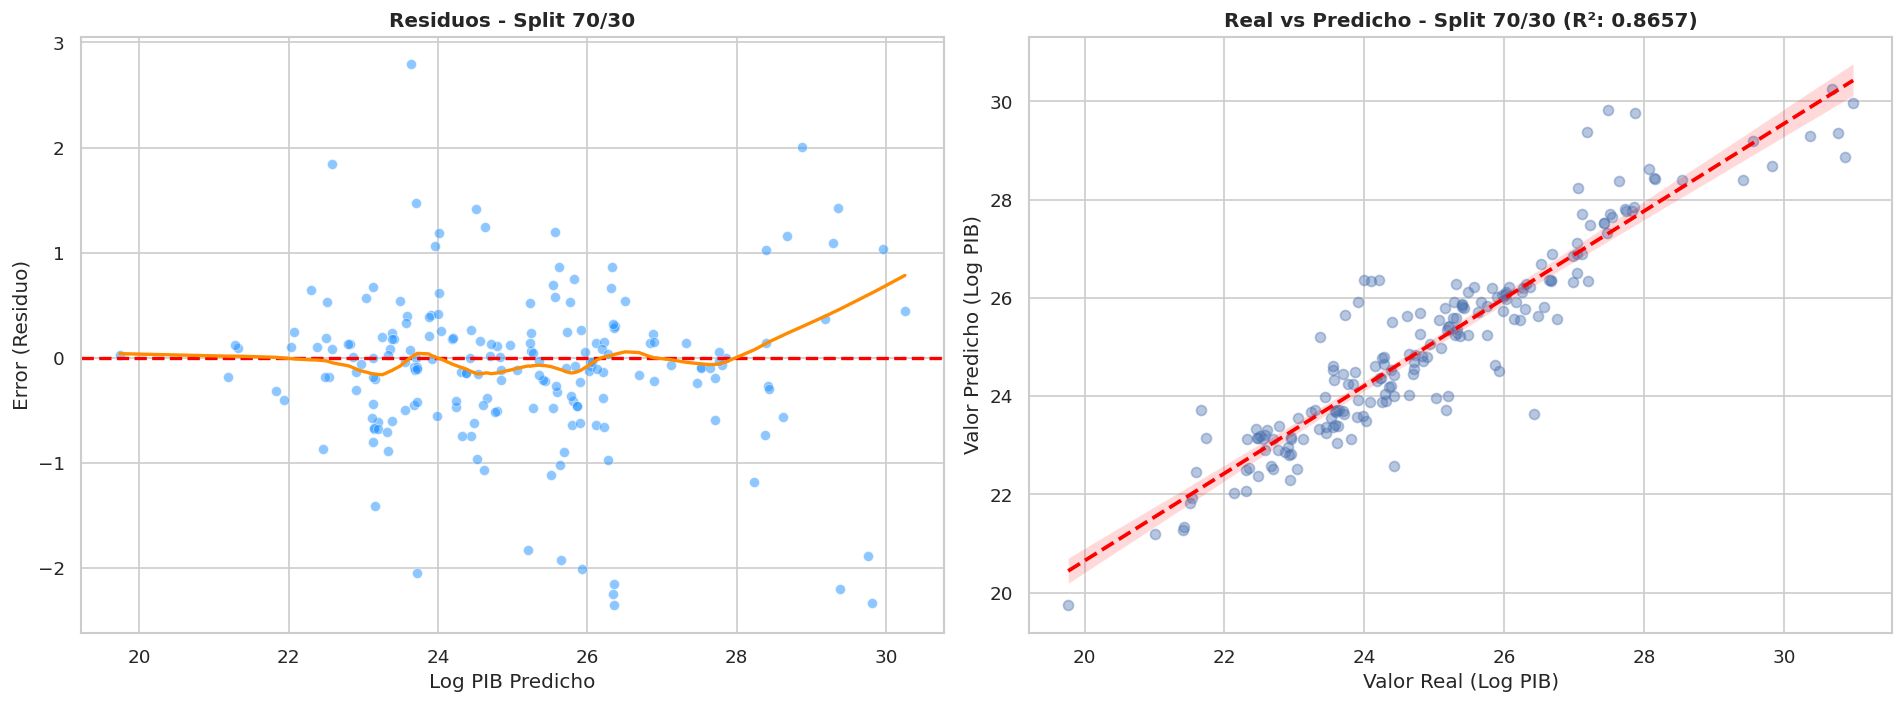

In [105]:
# ── CELDA 6: Ejecución del Split 70/30 ────────────────────────────────
modelo_final = evaluar_modelo_multiple(X, y, 0.30, "70/30", resumen_multiple)

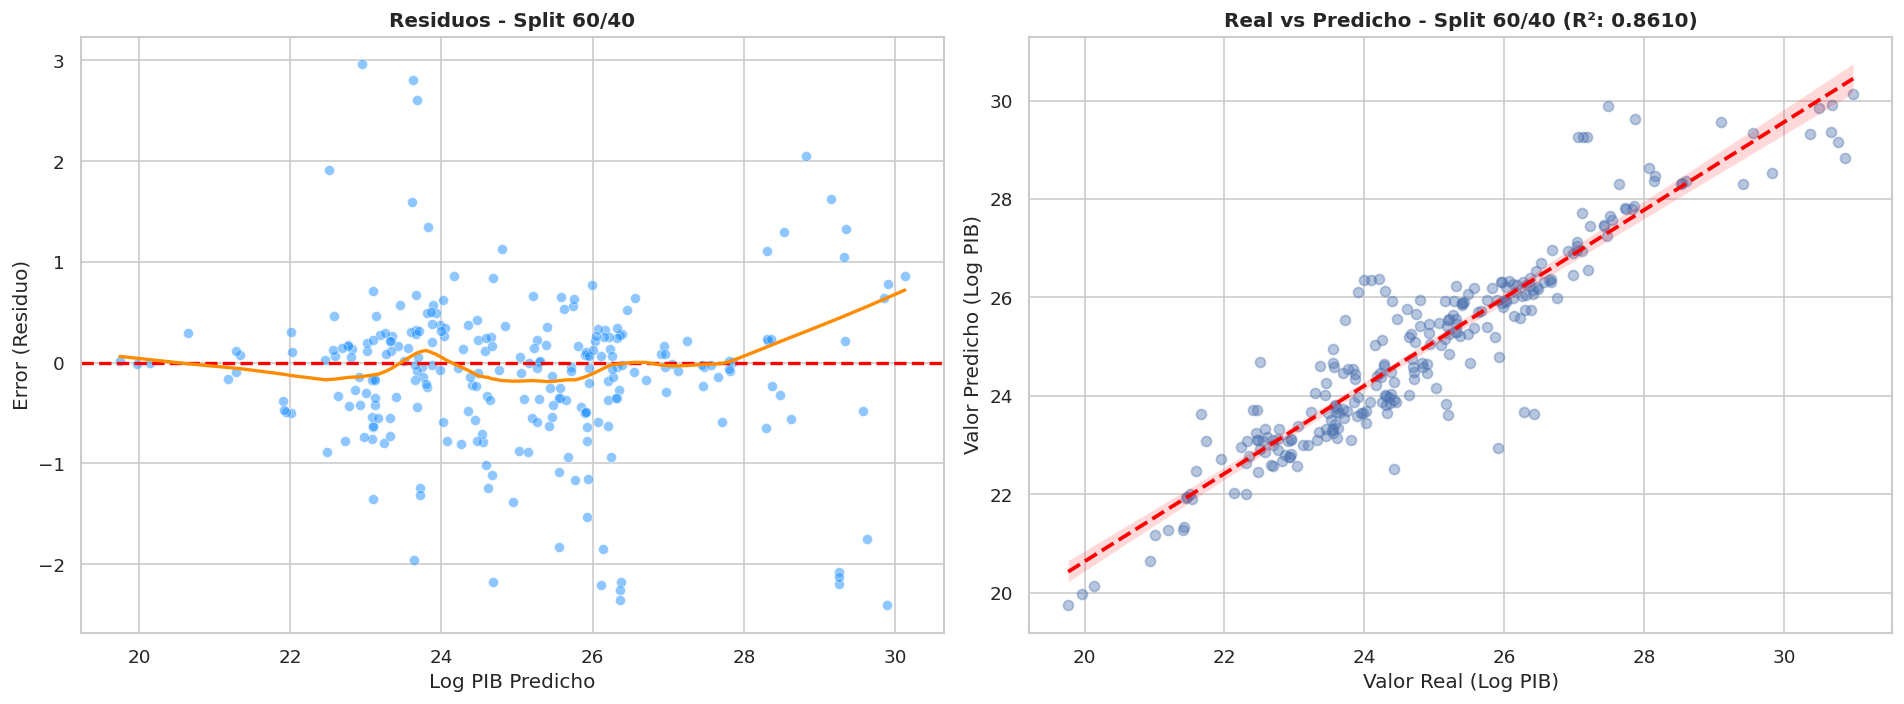

In [106]:
# ── CELDA 7: Ejecución del Split 60/40 ────────────────────────────────
modelo_60 = evaluar_modelo_multiple(X, y, 0.40, "60/40", resumen_multiple)

In [107]:

# ── CELDA 8: Tabla de Métricas ────────────────────────────────────────
df_resumen = pd.DataFrame(resumen_multiple)
display(df_resumen.round(4))

,Split,R2,RMSE,MAE
0,80/20,0.8962,0.6444,NaN
1,70/30,0.8657,0.7474,0.5045
2,60/40,0.8610,0.7761,0.5214


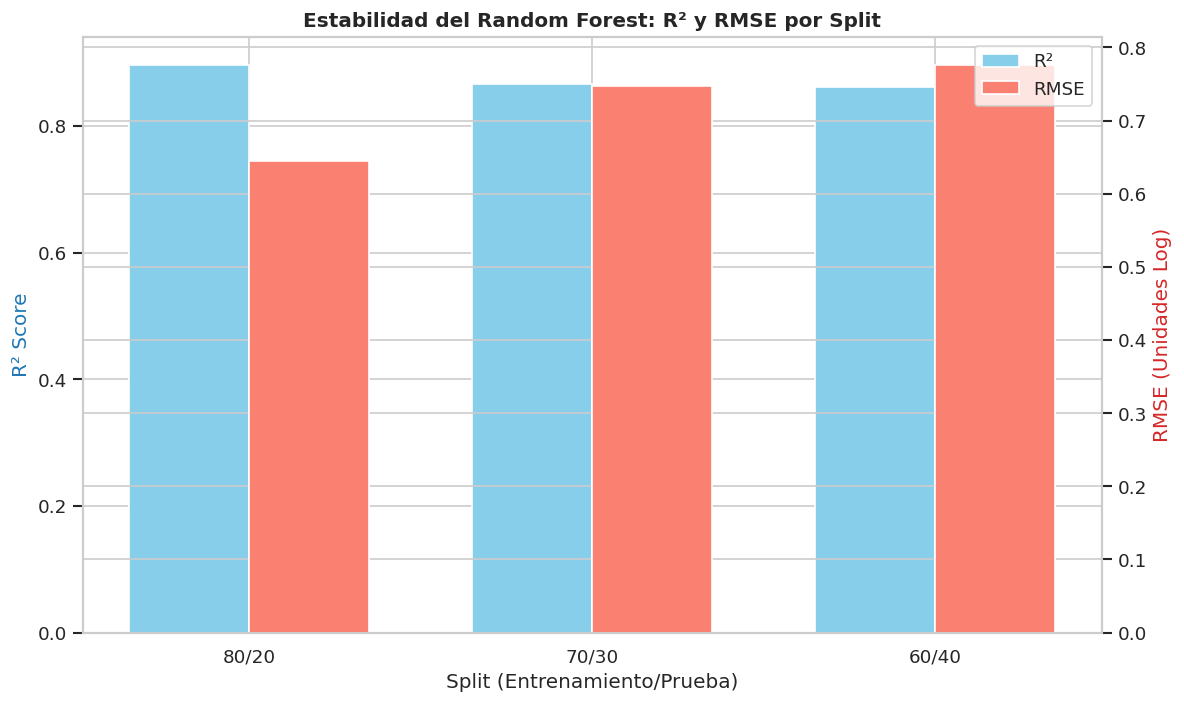

In [92]:
# ── CELDA 9: Gráfico de Barras Comparativo ────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_resumen['Split']))
width = 0.35

ax2 = ax1.twinx()

bar1 = ax1.bar(x - width/2, df_resumen['R2'], width, label='R²', color='skyblue')
bar2 = ax2.bar(x + width/2, df_resumen['RMSE'], width, label='RMSE', color='salmon')

ax1.set_xlabel('Split (Entrenamiento/Prueba)')
ax1.set_ylabel('R² Score', color='tab:blue')
ax2.set_ylabel('RMSE (Unidades Log)', color='tab:red')
ax1.set_xticks(x)
ax1.set_xticklabels(df_resumen['Split'])

plt.title('Estabilidad del Random Forest: R² y RMSE por Split', fontweight='bold')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### 🔍 Análisis Interpretativo
1. **Robustez del Modelo:** La variación del $R^2$ entre las tres particiones nos indica la estabilidad del árbol. Si la diferencia es marginal, el modelo generaliza bien las reglas de escala económica (Población -> PIB).
2. **Bandas Horizontales:** En los gráficos de *Log PIB Real vs Predicho*, se observan claramente líneas horizontales densas. Estas representan las **hojas del árbol**: como el modelo predice promedios por tramos, agrupa a los países en "zonas" escalonadas en lugar de crear una línea continua.
3. **El efecto de los Logaritmos:** Al usar escalas logarítmicas, un error (RMSE) aparentemente pequeño (ej. 0.5) en realidad representa desviaciones en escala exponencial en el mundo real, algo natural cuando comparamos potencias mundiales con países pequeños.

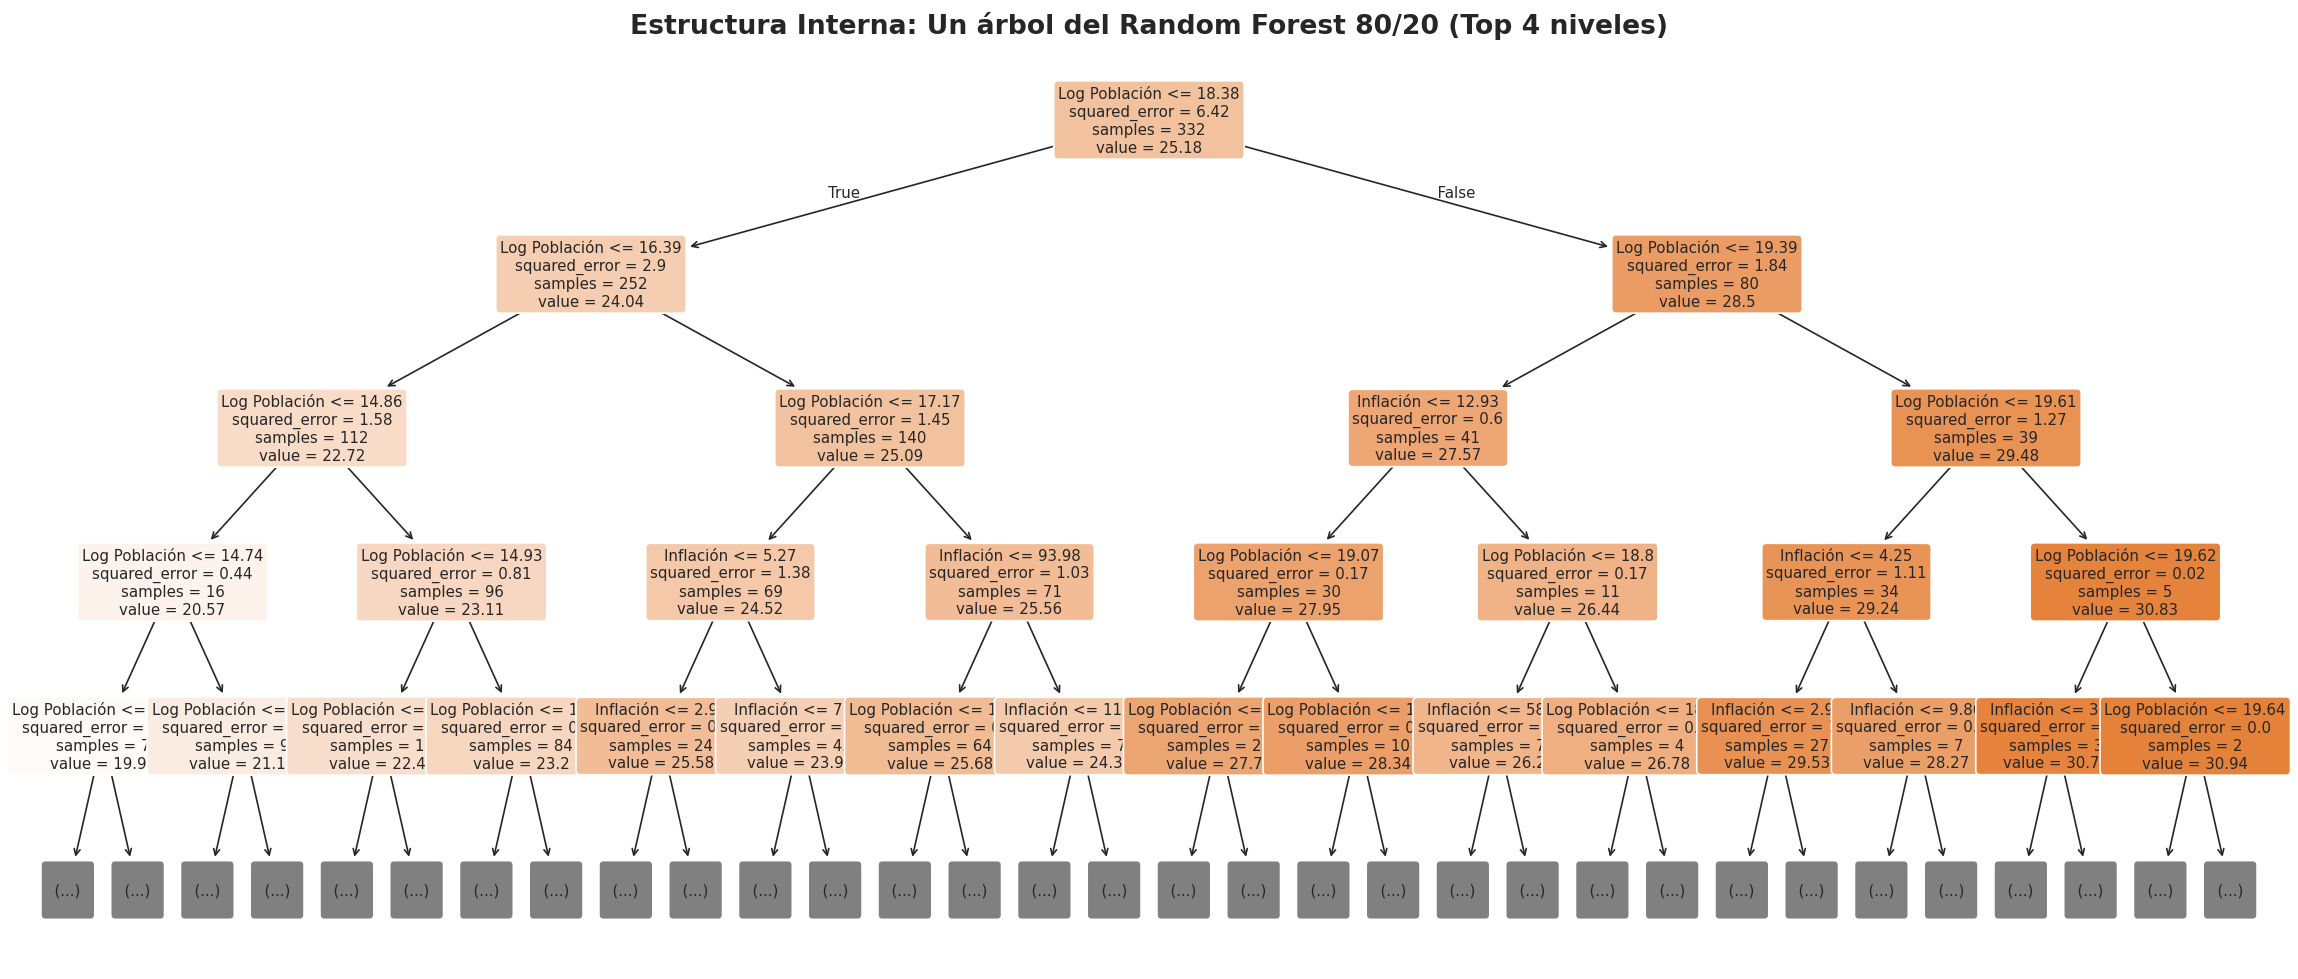

In [93]:
# ── CELDA 11: Árbol Real (Top 4 niveles del Bosque) ───────────────────
# Extraemos el primer árbol de nuestro modelo entrenado 80/20
arbol_ejemplo = modelo_80.estimators_[0]

plt.figure(figsize=(24, 10))
plot_tree(
    arbol_ejemplo, 
    max_depth=4, 
    feature_names=['Log Población', 'Inflación'], 
    filled=True, 
    rounded=True, 
    precision=2, 
    fontsize=9
)
plt.title("Estructura Interna: Un árbol del Random Forest 80/20 (Top 4 niveles)", fontsize=16, fontweight='bold')
plt.show()

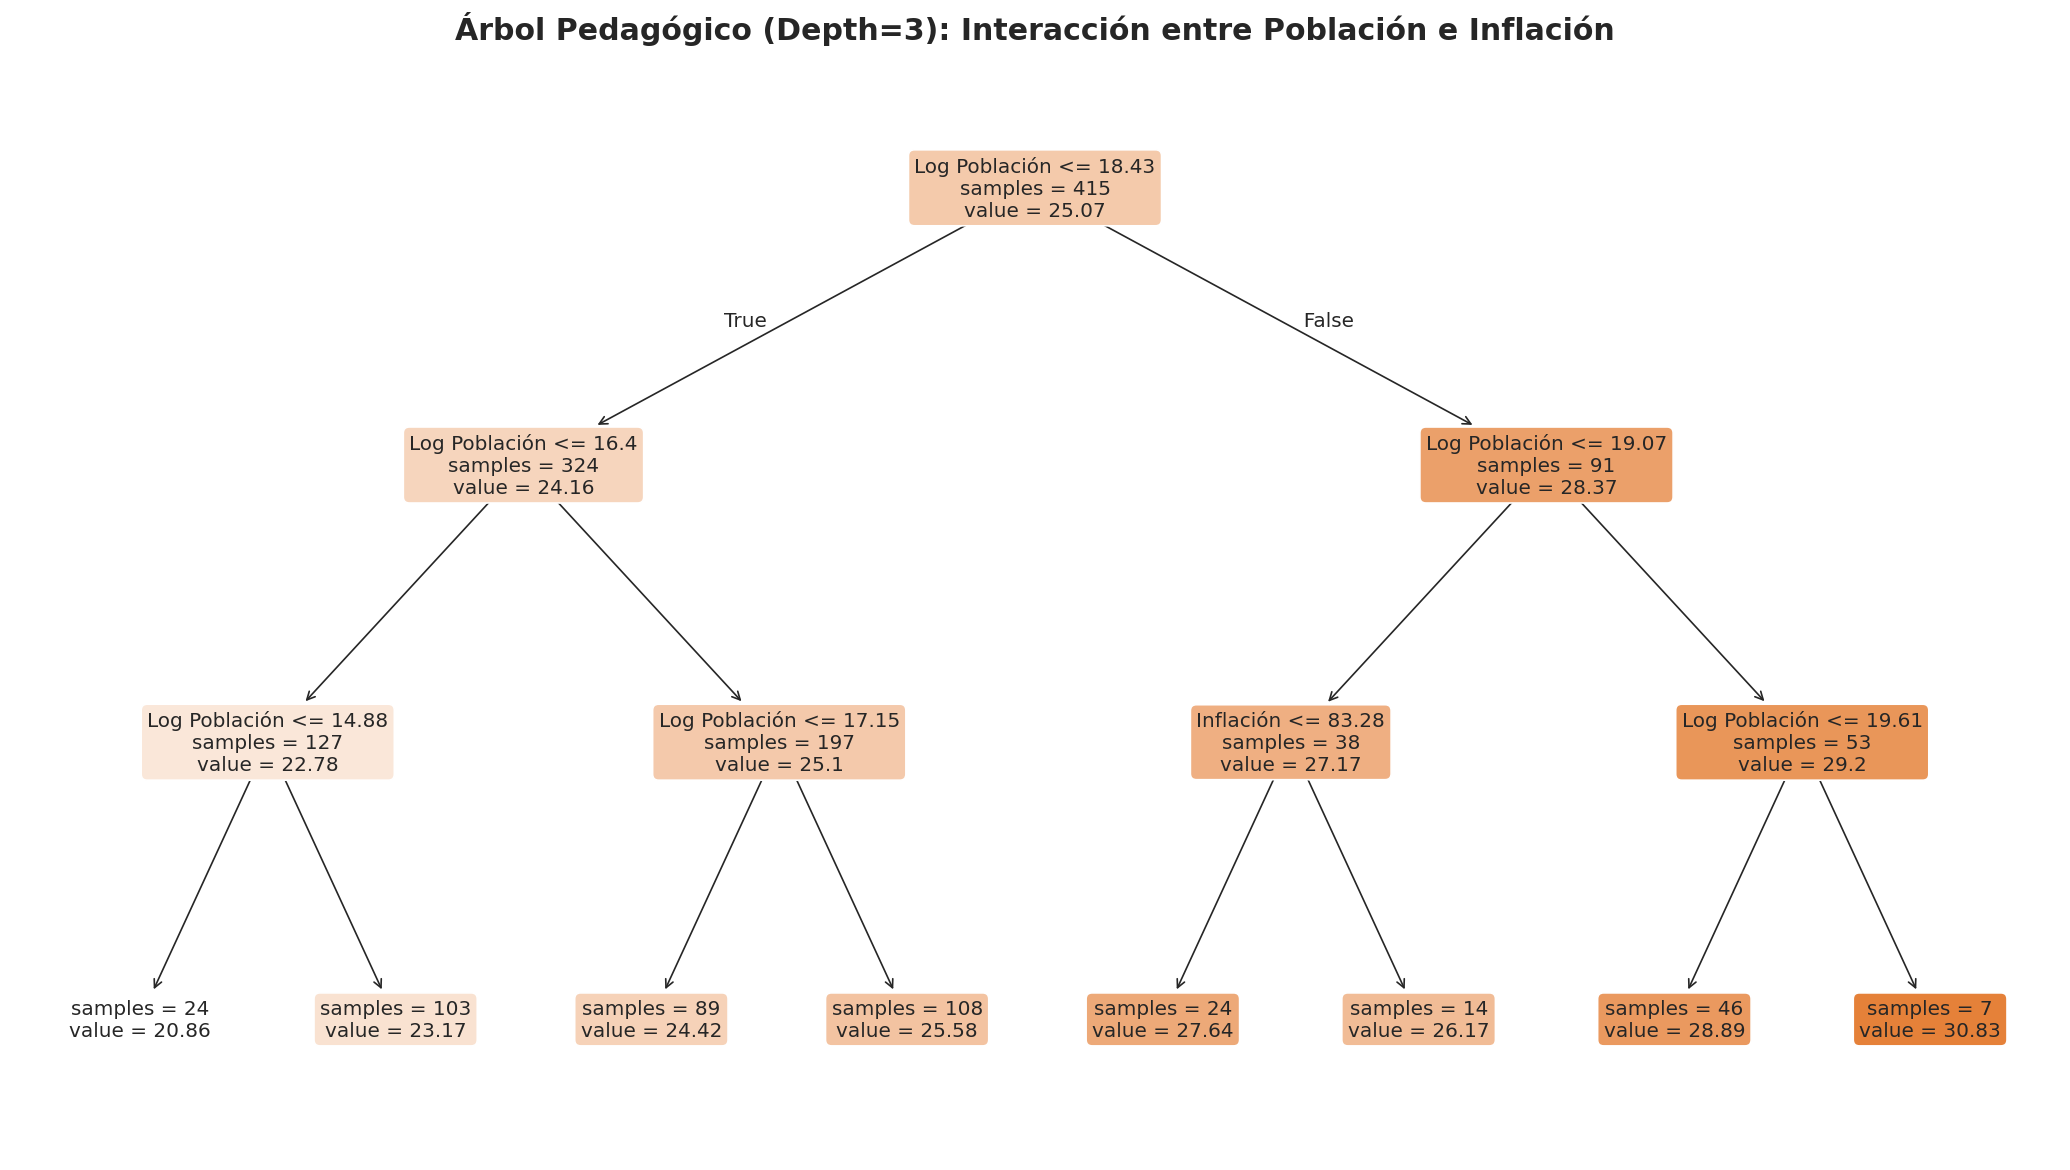

In [94]:
# ── CELDA 12: Árbol Pedagógico (Profundidad Controlada = 3) ───────────
# Entrenamos un Random Forest pequeño y de baja profundidad para entender las reglas clave
modelo_pedagogico = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)
modelo_pedagogico.fit(X, y)

# Extraemos un árbol de este bosque pedagógico
arbol_pedagogico = modelo_pedagogico.estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(
    arbol_pedagogico, 
    feature_names=['Log Población', 'Inflación'], 
    filled=True, 
    rounded=True, 
    impurity=False, # Ocultamos el error para lectura fácil
    precision=2, 
    fontsize=12
)
plt.title("Árbol Pedagógico (Depth=3): Interacción entre Población e Inflación", fontsize=18, fontweight='bold')
plt.show()

In [95]:
# ── CELDA 13: Exportación de Reglas ───────────────────────────────────
reglas_texto = export_text(arbol_pedagogico, feature_names=['Log Población', 'Inflación'])
print("📜 REGLAS MACROECONÓMICAS (Interacción Población-Inflación):")
print("-" * 70)
print(reglas_texto)

📜 REGLAS MACROECONÓMICAS (Interacción Población-Inflación):
----------------------------------------------------------------------
|--- Log Población <= 18.43
|   |--- Log Población <= 16.40
|   |   |--- Log Población <= 14.88
|   |   |   |--- value: [20.86]
|   |   |--- Log Población >  14.88
|   |   |   |--- value: [23.17]
|   |--- Log Población >  16.40
|   |   |--- Log Población <= 17.15
|   |   |   |--- value: [24.42]
|   |   |--- Log Población >  17.15
|   |   |   |--- value: [25.58]
|--- Log Población >  18.43
|   |--- Log Población <= 19.07
|   |   |--- Inflación <= 83.28
|   |   |   |--- value: [27.64]
|   |   |--- Inflación >  83.28
|   |   |   |--- value: [26.17]
|   |--- Log Población >  19.07
|   |   |--- Log Población <= 19.61
|   |   |   |--- value: [28.89]
|   |   |--- Log Población >  19.61
|   |   |   |--- value: [30.83]

